# Complexity of the Avoided Crossing — Frustrated Ising Ring (Cote et al. / Werner et al.)

#### About this notebook

Mirrors `AvoidedCrossing.ipynb` (5-qubit MWIS instance), adapted for the **frustrated Ising ring**
studied in Cote, Sauvage, Larocca, Jonsson, Cincio & Albash, *"Diabatic Quantum Annealing for the
Frustrated Ring Model"* (PRX Quantum, 2023), and built on further in Werner, Jonsson, Garcia-Saez,
Riera & Albas (2026) — the LZS ansatz paper we already implemented in `jax_utils.py` /
`sparse_grape.py` this session.

**Model** (N odd spins in a ring):
$$H_p = -\sum_{j=1}^N J_j \, Z_j Z_{j+1}, \qquad Z_{N+1}\equiv Z_1$$
$$J_j = \begin{cases} -J_R & j=N \\ J_L & j=(N{-}1)/2,\ (N{+}1)/2 \\ J & \text{otherwise}\end{cases}
\qquad 0 < J_R < J_L < J{=}1$$

Standard parameter choice across both papers: $(J_R, J_L, J) = (0.45, 0.5, 1)$.

**Important difference from the MWIS notebook**: this Hamiltonian has an *exact* global spin-flip
(Z2) symmetry $\Pi = \prod_i X_i$ commuting with $H(s)$ at every $s$. Its ground state is doubly
degenerate at $s=1$ ($|0\rangle^{\otimes N}$ and $|1\rangle^{\otimes N}$). Working in the full
$2^N$-dim space, the naive "find `argmin(E1-E0)`" AC-finder just finds this trivial degeneracy, not
the interesting perturbative AC around $s\approx 0.9$.

**Fix used here**: `src/z2_sector.py`'s `Z2SymmetricSector` class projects onto the genuine +1
eigenspace of $\Pi$ via the isometry $U$ with rows $(|x\rangle+|\bar x\rangle)/\sqrt2$ — NOT
`src.utils.Sector`, whose naive index truncation was checked numerically this session and found
to give incorrect eigenvalues for this Hamiltonian (max diff ~0.4-1.0 against the true spectrum,
not ~1e-14). The uniform superposition $|+\rangle^{\otimes N}$ (driver ground state) lies entirely
in the +1 sector, so annealing dynamics starting there stays confined to this sector for all $s$ —
verified via `.check_confined()` below. This also removes the $s=1$ degeneracy: the two full-space
degenerate ground states combine into one +1-sector state and one -1-sector state, so within the
+1 sector alone there IS a single isolated AC (confirmed at $s\approx0.899$, matching Werner et al.
Fig. 4 almost exactly).


#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh, expm_multiply
from src.annealing_utils import (
    get_longitudinal_hamiltonian,
    get_driver_hamiltonian,
    computational_basis,
)
from src.utils import Z2SymmetricSector
from src.jax_utils import SREJax
from src.utils import EntanglementEntropy
from tqdm import trange
import pickle

## Initialization of the target Hamiltonian

#### Hyperparameters — frustrated ring couplings

In [2]:
def frustrated_ring_jij_hz(N, J=1.0, JL=0.5, JR=0.45):
    """
    Build (jij, hz) for get_longitudinal_hamiltonian(jij, hz), which computes
        H = sum_{i<j} jij[i,j] Z_i Z_j + sum_i hz[i] Z_i     (NO extra sign)

    Target model (Cote et al. / Werner et al.):
        H_p = -sum_{j=1}^N J_j Z_j Z_{j+1}     (site N+1 == site 1, 1-indexed j)
        J_j = -J_R if j==N ; J_L if j==(N-1)/2 or (N+1)/2 ; J otherwise
        0 < J_R < J_L < J = 1

    The minus sign in H_p is folded into jij directly (get_longitudinal_hamiltonian
    applies no sign of its own), so jij[i,i+1] = -J_j.

    Ground state energy check: E0 = -(N-3)*J + J_R - 2*J_L  (verified numerically
    this session to match exactly for N=9,11,13).
    """
    assert N % 2 == 1, "N must be odd"
    jij = np.zeros((N, N))
    mid1 = (N - 1) // 2  # 1-indexed (N-1)/2
    mid2 = (N + 1) // 2  # 1-indexed (N+1)/2
    for j in range(1, N + 1):
        if j == N:
            Jj = -JR
        elif j == mid1 or j == mid2:
            Jj = JL
        else:
            Jj = J
        i0 = j - 1
        i1 = j % N
        jij[i0, i1] += -Jj
        jij[i1, i0] += -Jj
    hz = np.zeros(N)
    return jij, hz


# ── Standard parameter choice (Cote et al. Algorithm 2 / Werner et al. Fig. 4) ──
N = 7  # odd; N=9,11,13 feasible for full 2^N exact diagonalization
J, JL, JR = 1.0, 0.5, 0.45

jij, hz = frustrated_ring_jij_hz(N, J, JL, JR)
print("Jij matrix (nonzero entries only):")
for i in range(N):
    for j in range(i + 1, N):
        if jij[i, j] != 0:
            print(f"  ({i},{j}): {jij[i, j]:+.3f}")
print("\nhz vector (should be all zero — no local field in this model):")
print(hz)

Jij matrix (nonzero entries only):
  (0,1): -1.000
  (0,6): +0.450
  (1,2): -1.000
  (2,3): -0.500
  (3,4): -0.500
  (4,5): -1.000
  (5,6): -1.000

hz vector (should be all zero — no local field in this model):
[0. 0. 0. 0. 0. 0. 0.]


#### Hamiltonian Initialization

In [3]:
nqubits = N
target_hamiltonian = get_longitudinal_hamiltonian(
    jij, hz
)  # sparse scipy matrix, full 2^N space
driver_hamiltonian = get_driver_hamiltonian(
    nqubits=nqubits
)  # sparse scipy matrix, full 2^N space

# ── Verify: ground state energy against the closed-form formula ────────────────
E0_formula = -(N - 3) * J + JR - 2 * JL
vals_full = np.sort(
    eigsh(
        target_hamiltonian.astype(complex), k=4, which="SA", return_eigenvectors=False
    )
)
print(f"E0 formula          : {E0_formula:.4f}")
print(f"E0,E1 numeric (full) : {np.round(vals_full, 4)}")
print("(E0 should appear twice — exact Z2 ground-state degeneracy)")

E0 formula          : -4.5500
E0,E1 numeric (full) : [-4.55 -4.55 -4.45 -4.45]
(E0 should appear twice — exact Z2 ground-state degeneracy)


#### Z2 symmetric-sector projection (the fix)

In [4]:
# The uniform superposition (driver ground state) is manifestly +1 under the
# global flip Pi = prod_i X_i, so annealing dynamics from this initial state
# stays confined to the +1 sector for all s in [0,1] (H(s) commutes with Pi
# throughout, since target has only ZZ terms and driver only X terms).
sector = Z2SymmetricSector(nqubits, sign=+1)

dim = 2**nqubits
psi_init_full = np.ones(dim, dtype=complex) / np.sqrt(dim)
assert sector.check_confined(
    psi_init_full
), "initial state is not confined to the +1 sector!"

target_hamiltonian_s = sector.project(
    target_hamiltonian
)  # sparse, dim_sector x dim_sector
driver_hamiltonian_s = sector.project(driver_hamiltonian)
psi_init_s = sector.project(psi_init_full)

print(f"Full space dim   : {dim}")
print(f"Sector dim        : {sector.dim_sector}")
print(f"psi_init_s norm   : {np.linalg.norm(psi_init_s):.10f}")

# sanity check vs the ground-state degeneracy above: sector ground state
# should now be NON-degenerate (the two full-space GS combine into one +1
# and one -1 sector state)
vals_sector = np.sort(
    eigsh(
        target_hamiltonian_s.astype(complex), k=4, which="SA", return_eigenvectors=False
    )
)
print(
    f"E0,E1 numeric (sector): {np.round(vals_sector, 4)}  (should NOT show the doubling)"
)

Z2SymmetricSector: 64 states out of 128 (sign=+1)
Full space dim   : 128
Sector dim        : 64
psi_init_s norm   : 1.0000000000
E0,E1 numeric (sector): [-4.55 -4.45 -4.45 -3.45]  (should NOT show the doubling)


#### Analysis of the spectrum of the target Hamiltonian (sector space)

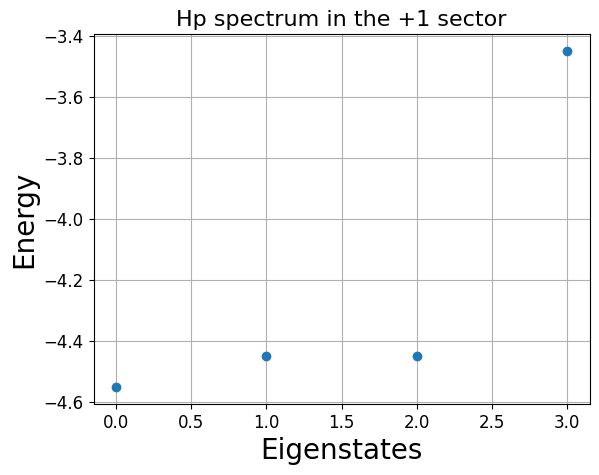

In [5]:
plt.plot(vals_sector, "o")
plt.xlabel("Eigenstates", fontsize=20)
plt.ylabel("Energy", fontsize=20)
plt.title("Hp spectrum in the +1 sector", fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid()
plt.show()

#### Avoided-crossing finder (within the +1 sector — no trivial s=1 degeneracy)

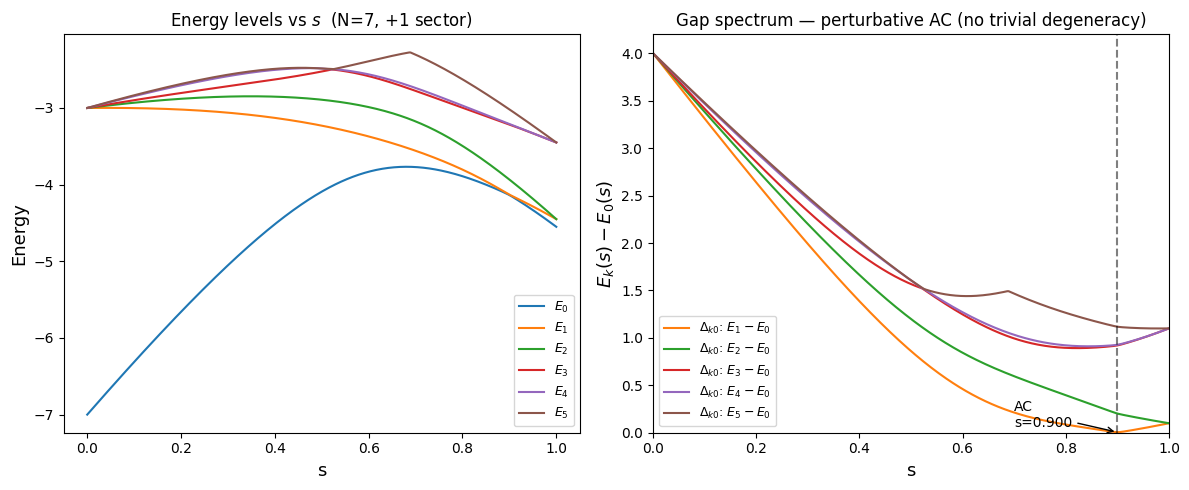

Minimum gap (Delta_10) = 5.714483e-03 at s = 0.8997
(Werner et al. Fig. 4 report s ~ 0.899 for J=1, JL=0.5, JR=0.45 in the large-N limit)


In [6]:
n_levels = 6
s_vals = np.linspace(0, 1, 400)
spectra = np.zeros((len(s_vals), n_levels))

for idx, s in enumerate(s_vals):
    H = (1 - s) * driver_hamiltonian_s + s * target_hamiltonian_s
    w = eigsh(H.astype(complex), k=n_levels, which="SA", return_eigenvectors=False)
    spectra[idx] = np.sort(w.real)

E0 = spectra[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for k in range(n_levels):
    ax.plot(s_vals, spectra[:, k], label=f"$E_{k}$")
ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("Energy", fontsize=13)
ax.set_title(f"Energy levels vs $s$  (N={N}, +1 sector)")
ax.legend(fontsize=9)

ax = axes[1]
colors = ["C1", "C2", "C3", "C4", "C5"]
for k in range(1, n_levels):
    gap = spectra[:, k] - E0
    ax.plot(s_vals, gap, color=colors[k - 1], label=f"$\\Delta_{{k0}}$: $E_{k}-E_0$")
ax.set_xlabel("s", fontsize=13)
ax.set_ylabel("$E_k(s) - E_0(s)$", fontsize=13)
ax.set_title("Gap spectrum — perturbative AC (no trivial degeneracy)")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)

min_gap = spectra[:, 1] - E0
s_mingap = s_vals[np.argmin(min_gap)]
ax.axvline(
    s_mingap, color="k", linestyle="--", alpha=0.5, label=f"min gap @ s={s_mingap:.3f}"
)
ax.annotate(
    f"AC\ns={s_mingap:.3f}",
    xy=(s_mingap, min_gap.min()),
    xytext=(s_mingap - 0.2, min_gap.min() + 0.05),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
)

plt.tight_layout()
plt.savefig("frustrated_ring_avoided_crossing.png", dpi=150)
plt.show()

print(f"Minimum gap (Delta_10) = {min_gap.min():.6e} at s = {s_mingap:.4f}")
print(
    "(Werner et al. Fig. 4 report s ~ 0.899 for J=1, JL=0.5, JR=0.45 in the large-N limit)"
)

#### Time evolution — linear ramp (sector space)

In [7]:
# ── time evolution parameters ─────────────────────────────────────────────────
nlevels = 8
tau = 50  # try a range of tau; the ring is expected to need LARGE tau
# for a linear ramp to reach the ground state (exponential
# slowdown at the AC) -- this is exactly the motivation for
# optimal control / LZS below.
time_steps = int(10 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]

In [8]:
dim_s = driver_hamiltonian_s.shape[0]
psi = psi_init_s.copy()

spectrum = np.zeros((time_steps, nlevels))
energy = np.zeros(time_steps)
probabilities = np.zeros((time_steps, nlevels))
psi_history_s = np.zeros((time_steps, dim_s), dtype=complex)
eigenstates_history_s = np.zeros((time_steps, dim_s, nlevels), dtype=complex)

for i, t in enumerate(time):
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian_s + (
        t / tau
    ) * target_hamiltonian_s
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)

    spectrum_t, eigenstates_t = eigsh(
        hamiltonian_t.astype(complex), which="SA", k=nlevels
    )
    order = np.argsort(spectrum_t)
    spectrum[i] = spectrum_t[order]
    eigenstates_raw = eigenstates_t[:, order].astype(complex)
    eigenstates_history_s[i] = eigenstates_raw

    probabilities[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_raw)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_raw).conj()
    ).real
    energy[i] = np.real(np.vdot(psi, hamiltonian_t @ psi))
    psi_history_s[i] = psi

min_time_gap = time[np.argmin(spectrum[:, 1] - spectrum[:, 0])]
print("final ground-state population:", probabilities[-1, 0])
print("final energy:", energy[-1])
print("min gap crossed at t =", min_time_gap, " (s =", min_time_gap / tau, ")")

final ground-state population: 0.22898551783195817
final energy: -4.472398611751431
min gap crossed at t = 44.98997995991984  (s = 0.8997995991983969 )


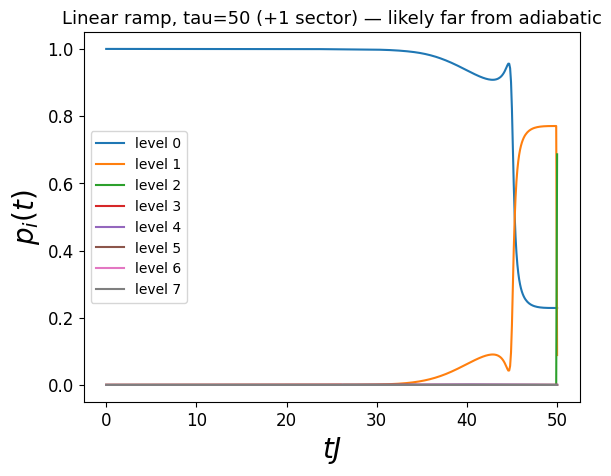

In [9]:
for i in range(nlevels):
    plt.plot(time, probabilities[:, i], label=f"level {i}")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$p_i(t)$", fontsize=20)
plt.title(
    f"Linear ramp, tau={tau} (+1 sector) — likely far from adiabatic", fontsize=13
)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

#### Compute Measure of Stabilizerness (SRE) and entanglement — lift to full space first

In [10]:
# SREJax and EntanglementEntropy are functionals of the FULL 2^N-dim wavefunction
# (SRE needs the full 4^N Pauli decomposition; entanglement entropy needs the
# full bipartition). Lift each sector state back before calling them.
sre = SREJax(n_qubits=nqubits, batch_size=4096)
entanglement_entropy = EntanglementEntropy(nqubits=nqubits, n_A=nqubits // 2)

magic = []
magic_gs_level = []
entanglement_entropy_history = []
entanglement_entropy_gs_level_history = []

# subsample if time_steps is large — SRE is O(4^N) per call
stride = max(1, time_steps // 500)

for i in trange(0, time_steps, stride):
    state_full = sector.lift(psi_history_s[i])
    gs_full = sector.lift(eigenstates_history_s[i, :, 0])
    magic.append(sre(state_full))
    magic_gs_level.append(sre(gs_full))
    entanglement_entropy_history.append(entanglement_entropy.von_neumann(state_full))
    entanglement_entropy_gs_level_history.append(
        entanglement_entropy.von_neumann(gs_full)
    )

time_sub = time[::stride]

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Building Pauli index tables for n=7 (16,384 Paulis)...
Done.
Bipartition: A=3 qubits (8d), B=4 qubits (16d)


100%|██████████| 500/500 [00:09<00:00, 54.27it/s]


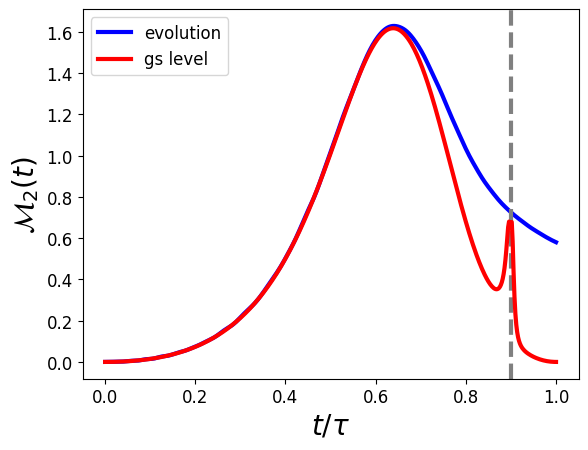

In [11]:
plt.plot(
    time_sub / tau, magic, label="evolution", color="blue", linestyle="-", linewidth=3
)
plt.axvline(s_mingap, linestyle="--", color="grey", lw=3)
plt.plot(
    time_sub / tau,
    magic_gs_level,
    label="gs level",
    color="red",
    linestyle="-",
    linewidth=3,
)
plt.xlabel(r"$t/\tau$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2(t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

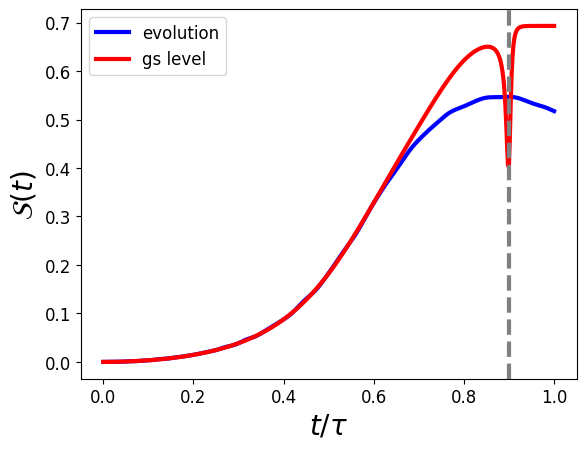

In [12]:
plt.plot(
    time_sub / tau,
    entanglement_entropy_history,
    label="evolution",
    color="blue",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time_sub / tau,
    entanglement_entropy_gs_level_history,
    label="gs level",
    color="red",
    linestyle="-",
    linewidth=3,
)
plt.axvline(s_mingap, linestyle="--", color="grey", lw=3)
plt.xlabel(r"$t/\tau$", fontsize=20)
plt.ylabel(r"$\mathcal{S}(t)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

## Optimal Control — LZS scheduler (Werner et al. ansatz, built this session)

##### Get Hyperparameters

In [13]:
number_parameters = 2  # M=2 plateaus/arms -> n_params = 3*M+1 = 7, matching
# Werner et al.'s reduction from Cote et al.'s ~100-parameter
# variational schedule down to 7 parameters
type = "LZS"

#### Sparse GRAPE (LZS)

In [15]:
from src.sparse_grape_method import SparseGRAPEModel, SparseGRAPETrainer

model = SparseGRAPEModel(
    initial_state=psi_init_s,
    target_hamiltonian=target_hamiltonian_s,
    initial_hamiltonian=driver_hamiltonian_s,
    reference_hamiltonian=target_hamiltonian_s,
    tf=tau,
    number_of_parameters=number_parameters,
    nsteps=time_steps,
    type=type,
    seed=42,
    random=True,
)

trainer = SparseGRAPETrainer(model, verbose=True)
opt_results = trainer.run()

  Initial energy    : -4.429968
  Gradient norm     : 3.937284e-01
  FD  grad[0]       : -2.450647e-01
  GRAPE grad[0]     : -2.052615e-01
  Relative error    : 1.624e-01
-4.454982309060259
-4.4677915057884094
-4.470691726762958
-4.481215640682694
-4.481879899727182
-4.482490769332398
-4.483512061138592
-4.492322142456032
-4.492353068201139
-4.495650805707731
-4.501486906948626
-4.50199611718284
-4.502787651848884
-4.50310193040117
-4.5036112463901095
-4.505058475361251
-4.508469192939296
-4.517504582822973
-4.519628675822117
-4.520508398158776
-4.523922843709818
-4.525419977781401
-4.525998932616314
-4.526751254330253
-4.527020945951544
-4.527716777185364
-4.528132156618911
-4.528378777967721
-4.5283838280723625
-4.528472438551664
-4.528474451133226
-4.52847878663369
-4.528478859754829
-4.528478966453202
-4.528478983213558
-4.528479415595917
-4.528480928376167
-4.528481192411743
-4.528481760402588
-4.528481973057224
-4.528482012783524
-4.528482131221665
-4.5284821312216685

Optimizati

#### JAX version (optional cross-check against GRAPE)

In [137]:
from src.jax_utils import JaxSchedulerModel, JaxTrainer

model_jax = JaxSchedulerModel(
    initial_state=psi_init_s,
    target_hamiltonian=target_hamiltonian_s,
    initial_hamiltonian=driver_hamiltonian_s,
    reference_hamiltonian=target_hamiltonian_s,
    tf=tau,
    nsteps=time_steps,
    number_of_parameters=number_parameters,
    type=type,
    seed=42,
    mode="annealing ansatz",
    random=False,
)

trainer_jax = JaxTrainer(
    model_jax, maxiter=500, tol=1e-6, ftol=1e-5, gtol=1e-4, verbose=True
)
results_jax = trainer_jax.run()

print("\nGRAPE final energy:", opt_results["energy"])
print("JAX   final energy:", results_jax["energy"])

JIT compilation done.
-2.479589712856887
-2.479692354450034
-2.4797462912518076
-2.4797511823967664

Optimization success : True
Final energy         : -2.479751
Message              : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

GRAPE final energy: -2.4790106085032884
JAX   final energy: -2.4797511823967664


#### Check the results — decode the optimized LZS schedule

segment boundary times (t_bounds): [ 0.         12.80650791 23.41706818 28.87510459 39.78600662 50.        ]
waypoint s-values (s_way)         : [0.         0.79045767 0.54719523 1.        ]


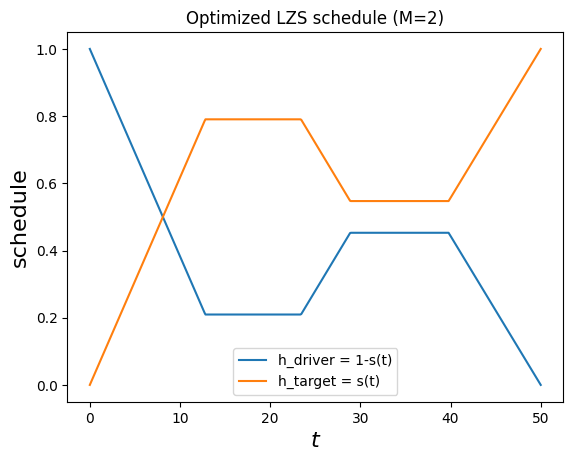

h_driver[0]  = 1.000000   (should be 1)
h_driver[-1] = 0.000000   (should be 0)
h_target[0]  = 0.000000   (should be 0)
h_target[-1] = 1.000000   (should be 1)


In [184]:
t_bounds, s_way = model.get_lzs_waypoints()
print("segment boundary times (t_bounds):", t_bounds)
print("waypoint s-values (s_way)         :", s_way)

h_driver, h_target = model.get_driving()
plt.plot(time, h_driver, label="h_driver = 1-s(t)")
plt.plot(time, h_target, label="h_target = s(t)")
plt.xlabel(r"$t$", fontsize=16)
plt.ylabel("schedule", fontsize=16)
plt.title(f"Optimized LZS schedule (M={number_parameters})")
plt.legend()
plt.show()

print(f"h_driver[0]  = {h_driver[0]:.6f}   (should be 1)")
print(f"h_driver[-1] = {h_driver[-1]:.6f}   (should be 0)")
print(f"h_target[0]  = {h_target[0]:.6f}   (should be 0)")
print(f"h_target[-1] = {h_target[-1]:.6f}   (should be 1)")

#### Propagate the optimized schedule and check ground-state population

In [185]:
psi = psi_init_s.copy()
psi_history_optimalcontrol_s = np.zeros((time_steps, dim_s), dtype=complex)
energy_optimal = np.zeros(time_steps)
probabilities_optimalcontrol = np.zeros((time_steps, nlevels))
spectrum_optimalcontrol = np.zeros((time_steps, nlevels))

for i, t in enumerate(time):
    hamiltonian_t = (
        h_driver[i] * driver_hamiltonian_s + h_target[i] * target_hamiltonian_s
    )
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    psi_history_optimalcontrol_s[i] = psi

    values, eigenstates = eigsh(hamiltonian_t.astype(complex), which="SA", k=nlevels)
    order = np.argsort(values)
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i] = values[order]
    probabilities_optimalcontrol[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    ).real
    energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi)).real

print(
    "Final ground-state population (optimal control):",
    probabilities_optimalcontrol[-1, 0],
)
print("Compare to linear-ramp final ground-state population:", probabilities[-1, 0])

Final ground-state population (optimal control): 0.8245084603195506
Compare to linear-ramp final ground-state population: 0.22898551783196763


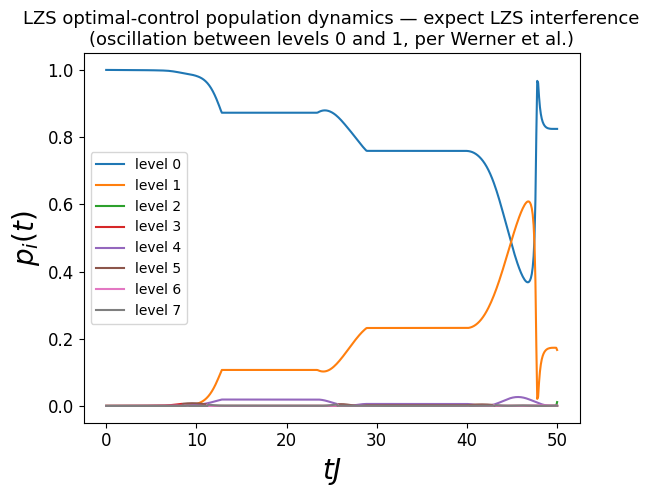

In [186]:
for i in range(nlevels):
    plt.plot(time, probabilities_optimalcontrol[:, i], label=f"level {i}")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$p_i(t)$", fontsize=20)
plt.title(
    "LZS optimal-control population dynamics — expect LZS interference\n(oscillation between levels 0 and 1, per Werner et al.)",
    fontsize=13,
)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

#### Check the results

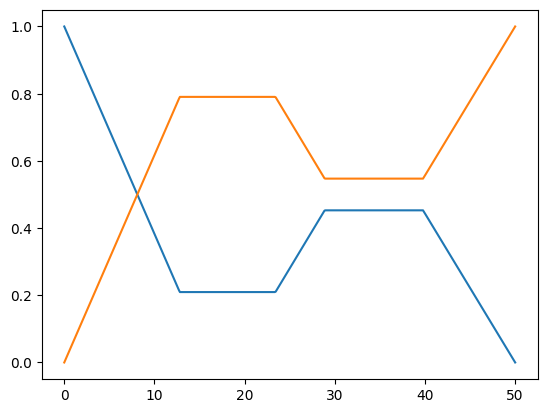

(-4.5284821312216685+0j)


In [187]:
# ── energy + state history for both schedules ─────────────────────────────────
energy_linear = np.zeros(time_steps)
energy_optimal = np.zeros(time_steps)
psi_linear_history = np.zeros((time_steps, psi_init_s.shape[0]), dtype=complex)
psi_optimal_history = np.zeros((time_steps, psi_init_s.shape[0]), dtype=complex)

# optimal
h_driver, h_target = model.get_driving()

# initialize the state

plt.plot(time, h_driver)
plt.plot(time, h_target)
plt.show()


# initialization
psi = psi_init_s.copy()
psi_history_optimalcontrol = np.zeros((time_steps, psi_init_s.shape[0]), dtype=complex)
for i, t in enumerate(time):

    hamiltonian_t = (
        h_driver[i] * driver_hamiltonian_s + target_hamiltonian_s * h_target[i]
    )
    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
    psi_history_optimalcontrol[i] = psi
    # for r in range(nlevels):
    #    probabilities_optimalcontrol[i,r]=(eigenstates_history[i,:,r].conj().T.dot(psi))*np.conjugate((eigenstates_history[i,:,r].conj().T.dot(psi)))

print(psi.conj().dot(target_hamiltonian_s.dot(psi)))

##### Warm Starting

In [ ]:
import numpy as np
from scipy.sparse.linalg import eigsh
from src.sparse_grape_method import SparseGRAPEModel, SparseGRAPETrainer


def get_driver_ground_state(driver_hamiltonian):
    """
    Returns the true ground state of the driver Hamiltonian.

    This is NOT the same as the uniform superposition np.ones(dim)/sqrt(dim)
    for n > 1 qubits with a transverse-field driver — the two only coincide
    when all driver eigenvalues are degenerate, which is not the case here.
    Using the wrong initial state shifts the gradient landscape seen by GRAPE
    and prevents convergence.
    """
    _, psi = eigsh(driver_hamiltonian.astype(complex), which="SA", k=1)
    return psi[:, 0].astype(complex)


def run_fcrab_warm_start(
    psi_init,
    target_hamiltonian,  # renamed: no _s suffix, full space
    driver_hamiltonian,  # renamed: no _s suffix, full space
    tau,
    time_steps,
    dim_schedule=[2, 4, 8, 16, 32],
    nr=5,
    maxiter=500,
    ftol=1e-9,
    gtol=1e-9,
    verbose=True,
):
    """
    Progressive warm-start F-CRAB optimisation, matching the notebook exactly.

    Key invariants
    --------------
    best_params layout : [a_drv_0, …, a_drv_{Nc-1},  a_tgt_0, …, a_tgt_{Nc-1}]
                         i.e. first Nc entries = driver coefficients,
                              next  Nc entries = target coefficients.

    When promoting from Nc_prev → Nc:
        init_params[:Nc_prev]          ← best_params[:Nc_prev]          (old driver)
        init_params[Nc : Nc+Nc_prev]   ← best_params[Nc_prev : 2*Nc_prev]  (old target)
        new slots are zero-initialised.

    best_omegas always has shape (Nc_current,) — the frequencies that go with
    the current best_params.  They are prepended to each next level's new
    random frequencies so the optimiser inherits the converged landscape.
    """
    best_params = None
    best_omegas = None
    best_energy = np.inf
    best_psi = None
    best_h_driver = None
    best_h_target = None

    for level_idx, dim in enumerate(dim_schedule):
        # number of modes that were already optimised at the previous level
        dim_prev = dim_schedule[level_idx - 1] if level_idx > 0 else 0
        delta = dim - dim_prev  # new modes added at this level

        if verbose:
            print(f"\n{'='*52}")
            print(f"  N_c = {dim}  (+{delta} new modes, {nr} restarts)")
            print(f"{'='*52}")

        level_best_energy = np.inf
        level_best_params = None
        level_best_omegas = None
        level_best_psi = None
        level_best_h_driver = None
        level_best_h_target = None

        for restart in range(nr):
            rng = np.random.default_rng()  # fresh seed each restart

            # ── frequencies ──────────────────────────────────────────────────
            # Only the *new* modes get randomised frequencies.
            # The old (converged) frequencies are inherited unchanged.
            new_omegas = (
                np.pi
                * np.arange(dim_prev + 1, dim + 1)
                * (1.0 + rng.uniform(-0.5, 0.5, delta))
                / tau
            )

            full_omegas = (
                np.concatenate([best_omegas, new_omegas])
                if best_omegas is not None
                else new_omegas
            )

            # ── parameter warm-start ──────────────────────────────────────────
            # Layout: [a_drv(dim), a_tgt(dim)]
            # Carry over old driver and target coefficients; zero the new slots.
            init_params = np.zeros(2 * dim)
            if best_params is not None:
                # old driver amplitudes
                init_params[:dim_prev] = best_params[:dim_prev]
                # old target amplitudes
                # NOTE: in best_params the target block starts at index dim_prev
                #       (size of the *previous* dim, not the current dim).
                init_params[dim : dim + dim_prev] = best_params[dim_prev : 2 * dim_prev]

            # ── model ─────────────────────────────────────────────────────────
            model = SparseGRAPEModel(
                initial_state=psi_init,
                target_hamiltonian=target_hamiltonian,
                initial_hamiltonian=driver_hamiltonian,
                reference_hamiltonian=target_hamiltonian,
                tf=tau,
                number_of_parameters=dim,
                nsteps=time_steps,
                type="F-CRAB",
                seed=42,
                mode="annealing ansatz",
                random=False,
            )

            # Override frequencies and recompute the sin basis.
            # This must happen AFTER model construction (which sets its own
            # default omegas) and BEFORE trainer.run() reads _sin_basis.
            model.omegas = full_omegas
            model._sin_basis = np.sin(np.outer(full_omegas, model.time))
            model.parameters = init_params.copy()

            # ── optimise ──────────────────────────────────────────────────────
            trainer = SparseGRAPETrainer(
                model,
                maxiter=maxiter,
                ftol=ftol,
                gtol=gtol,
                verbose=verbose,
            )
            res = trainer.run()

            if verbose:
                print(f"  └─ restart {restart+1}/{nr}  E = {res['energy']:.8f}")

            if res["energy"] < level_best_energy:
                level_best_energy = res["energy"]
                level_best_params = res["parameters"].copy()
                level_best_omegas = full_omegas.copy()
                level_best_psi = res["psi"].copy()
                level_best_h_driver = res["h_driver"].copy()
                level_best_h_target = res["h_target"].copy()

        # promote this level's best if it beats the global best
        if level_best_energy < best_energy:
            best_energy = level_best_energy
            best_params = level_best_params
            best_omegas = level_best_omegas
            best_psi = level_best_psi
            best_h_driver = level_best_h_driver
            best_h_target = level_best_h_target

        if verbose:
            print(f"\n  → best energy at N_c={dim}: {best_energy:.8f}")

    return {
        "h_driver": best_h_driver,
        "h_target": best_h_target,
        "energy": best_energy,
        "psi": best_psi,
        "parameters": best_params,
        "omegas": best_omegas,
    }


# ── usage ─────────────────────────────────────────────────────────────────────
# CRITICAL: psi_init must be the actual GS of the driver, not the uniform
# superposition.  The two differ for n > 1 qubits.
#
#   WRONG:  psi_init = np.ones(dim, dtype=complex) / np.sqrt(dim)
#   RIGHT:  psi_init = get_driver_ground_state(driver_hamiltonian)

if __name__ == "__main__":
    # these would be defined in your study script
    psi_init = get_driver_ground_state(driver_hamiltonian)

    results = run_fcrab_warm_start(
        psi_init=psi_init,
        target_hamiltonian=target_hamiltonian,
        driver_hamiltonian=driver_hamiltonian,
        tau=tau,
        time_steps=time_steps,
        dim_schedule=[2, 4, 8, 16, 32],
        nr=5,
        maxiter=500,
        ftol=1e-9,
        gtol=1e-9,
        verbose=True,
    )

    h_driver = results["h_driver"]
    h_target = results["h_target"]
    psi_final = results["psi"]
    energy = results["energy"]


  N_c = 2  (+2 new modes, 5 restarts)
  Initial energy    : -30.680804
  Gradient norm     : 1.605334e+00


KeyboardInterrupt: 

In [ ]:
h_driver = results["h_driver"]
h_target = results["h_target"]

psi = psi_init.copy()
psi_history_optimalcontrol = np.zeros(
    (time_steps, psi_init.shape[0]), dtype=complex
)  # must be complex
energy_optimal = np.zeros(time_steps)
probabilities_optimalcontrol = np.zeros((time_steps, nlevels))
spectrum_optimalcontrol = np.zeros((time_steps, nlevels))

for i, t in enumerate(time):
    hamiltonian_t = h_driver[i] * driver_hamiltonian + h_target[i] * target_hamiltonian

    psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)  # propagate first

    psi_history_optimalcontrol[i] = psi  # then store

    values, eigenstates = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(values)
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i] = values[order]

    probabilities_optimalcontrol[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    ).real

    energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi)).real

print(psi.conj().dot(target_hamiltonian.dot(psi)).real)
print(probabilities_optimalcontrol[-1, 0])

-31.99965239404614
0.9916906520918493


In [ ]:
h_driver = results["h_driver"]
h_target = results["h_target"]
psi_final = results["psi"]
energy = results["energy"]
print(results.keys())

energy_optimal = np.zeros(time_steps)
probabilities_optimalcontrol = np.zeros((time_steps, nlevels))
spectrum_optimalcontrol = np.zeros((time_steps, nlevels))
for i, t in enumerate(time):
    psi = psi_history_optimalcontrol[i]
    hamiltonian_t = (1 - t / tau) * driver_hamiltonian + target_hamiltonian * t / tau
    values, eigenstates = eigsh(hamiltonian_t, which="SA", k=nlevels)
    order = np.argsort(values)
    spectrum_t = values[order]
    eigenstates_t = eigenstates[:, order]
    spectrum_optimalcontrol[i] = spectrum_t
    # overlap
    probabilities_optimalcontrol[i] = (
        np.einsum("i,ia->a", psi.conj(), eigenstates_t)
        * np.einsum("i,ia->a", psi.conj(), eigenstates_t).conj()
    )
    energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi))
print(t)
print(psi.conj().dot(target_hamiltonian.dot(psi)))
print(probabilities_optimalcontrol[-1, 0])

dict_keys(['h_driver', 'h_target', 'energy', 'psi', 'parameters', 'omegas'])


/tmp/ipykernel_60483/330145070.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimalcontrol[i] = (
/tmp/ipykernel_60483/330145070.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  energy_optimal[i] = psi.conj().dot(hamiltonian_t.dot(psi))


10.0
(-31.99965239404614+1.7763568394002505e-15j)
0.9916906520918931


In [ ]:
print(spectrum_optimalcontrol[-1])

[-32.         -31.96       -30.62666667 -30.62666667 -30.62666667
 -29.98       -29.98       -29.29333333 -29.29333333 -29.29333333]


In [ ]:
print(f"h_driver[0]  = {h_driver[0]:.6f}")  # should be 1
print(f"h_driver[-1] = {h_driver[-1]:.6f}")  # should be 0
print(f"h_target[0]  = {h_target[0]:.6f}")  # should be 0
print(f"h_target[-1] = {h_target[-1]:.6f}")  # should be 1

h_driver[0]  = 1.000000
h_driver[-1] = 0.000000
h_target[0]  = 0.000000
h_target[-1] = 0.793654


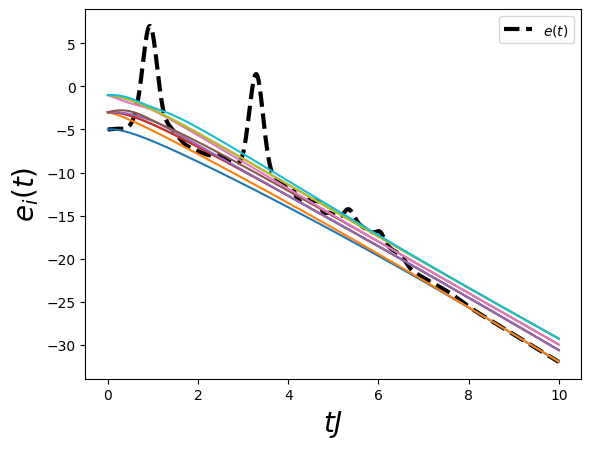

In [ ]:
plt.plot(
    time, energy_optimal, color="black", linestyle="--", linewidth=3, label=r"$e(t)$"
)
for i in range(spectrum_optimalcontrol.shape[1]):

    plt.plot(time, spectrum_optimalcontrol[:, i])
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$e_i(t)$", fontsize=20)
plt.legend()
plt.show()

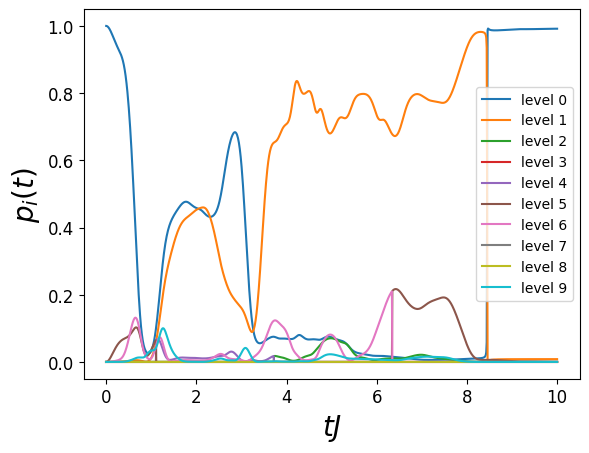

In [ ]:
for i in range(nlevels):
    plt.plot(time, probabilities_optimalcontrol[:, i], label=f"level {i}")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$p_i(t)$", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

##### Stabilizer Renyi Entropy

In [188]:
from tqdm import trange

# single state
magic_optimal_control = []
entanglememt_entropy_history_optimal_control = []
# subsample if time_steps is large — SRE is O(4^N) per call
stride = max(1, time_steps // 500)

for i in trange(0, time_steps, stride):

    state = state_full = sector.lift(psi_history_optimalcontrol[i])
    magic_optimal_control.append(sre((state)))
    entanglememt_entropy_history_optimal_control.append(
        entanglement_entropy.von_neumann((state))
    )

100%|██████████| 500/500 [00:04<00:00, 106.83it/s]


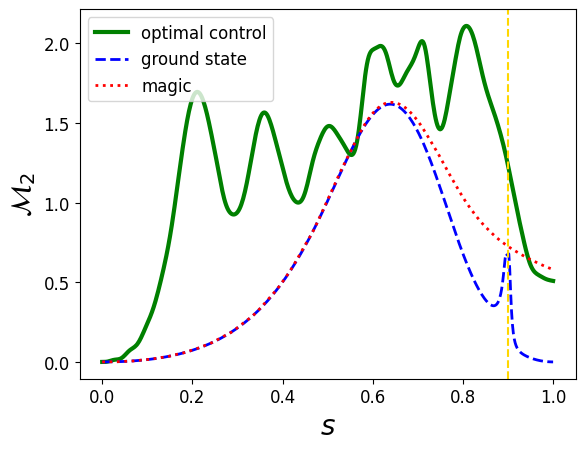

In [189]:
plt.plot(
    time_sub / tau,
    magic_optimal_control,
    label="optimal control",
    color="green",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time_sub / tau,
    magic_gs_level,
    label="ground state",
    color="blue",
    linestyle="--",
    linewidth=2,
)
plt.plot(time_sub / tau, magic, label="magic", color="red", linestyle=":", linewidth=2)
plt.axvline(min_time_gap / tau, linestyle="--", color="gold")
plt.xlabel(r"$s$", fontsize=20)
plt.ylabel(r"$\mathcal{M}_2$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

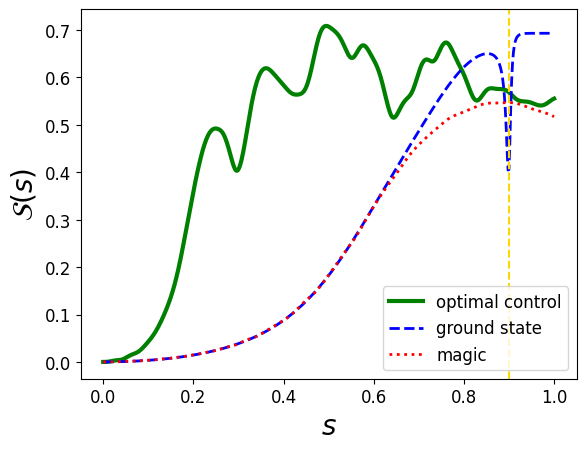

In [191]:
plt.plot(
    time_sub / tau,
    entanglememt_entropy_history_optimal_control,
    label="optimal control",
    color="green",
    linestyle="-",
    linewidth=3,
)
plt.plot(
    time_sub / tau,
    entanglement_entropy_gs_level_history,
    label="ground state",
    color="blue",
    linestyle="--",
    linewidth=2,
)
plt.plot(
    time_sub / tau,
    entanglement_entropy_history,
    label="magic",
    color="red",
    linestyle=":",
    linewidth=2,
)
plt.axvline(min_time_gap / tau, linestyle="--", color="gold")
plt.xlabel(r"$s$", fontsize=20)
plt.ylabel(r"$\mathcal{S}(s)$", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()

##### Energy Path and NON-STABILIZERNESS through the optimization

[np.float64(-4.454982309060259), np.float64(-4.4677915057884094), np.float64(-4.470691726762958), np.float64(-4.481215640682694), np.float64(-4.481879899727182), np.float64(-4.482490769332398), np.float64(-4.483512061138592), np.float64(-4.492322142456032), np.float64(-4.492353068201139), np.float64(-4.495650805707731), np.float64(-4.501486906948626), np.float64(-4.50199611718284), np.float64(-4.502787651848884), np.float64(-4.50310193040117), np.float64(-4.5036112463901095), np.float64(-4.505058475361251), np.float64(-4.508469192939296), np.float64(-4.517504582822973), np.float64(-4.519628675822117), np.float64(-4.520508398158776), np.float64(-4.523922843709818), np.float64(-4.525419977781401), np.float64(-4.525998932616314), np.float64(-4.526751254330253), np.float64(-4.527020945951544), np.float64(-4.527716777185364), np.float64(-4.528132156618911), np.float64(-4.528378777967721), np.float64(-4.5283838280723625), np.float64(-4.528472438551664), np.float64(-4.528474451133226), np.flo

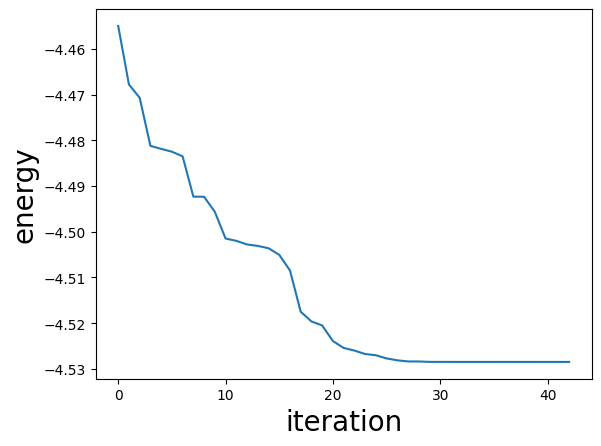

43
(500,)


In [192]:
print(model.history)
plt.plot(np.arange(len(model.history)), model.history)
plt.xlabel("iteration", fontsize=20)
plt.ylabel("energy", fontsize=20)
# plt.yscale('log')
plt.show()
print(len(model.history))


print(model.history_drivings[0][0].shape)

In [193]:
total_magic = []
total_entanglement = []
delta_t = model.tf / model.nsteps
print(len(model.history_drivings[0]))
for i in trange(0, len(model.history_drivings), 1):

    h_driver, h_target = model.history_drivings[i]

    # initialization
    psi = psi_init_s.copy()
    psi_history_optimalcontrol = np.zeros(
        (time_steps, psi_init_s.shape[0]), dtype=complex
    )
    magic = []
    entanglement = []
    for i, t in enumerate(time):
        hamiltonian_t = (
            h_driver[i] * driver_hamiltonian_s + target_hamiltonian_s * h_target[i]
        )
        psi = expm_multiply(-1j * delta_t * hamiltonian_t, psi)
        psi_history_optimalcontrol[i] = psi
        magic.append(sre(sector.lift(psi)))
        entanglement.append(entanglement_entropy.von_neumann(sector.lift(psi)))
    total_magic.append(delta_t * np.sum(magic))
    total_entanglement.append(delta_t * np.sum(entanglement))

2


100%|██████████| 43/43 [03:38<00:00,  5.08s/it]


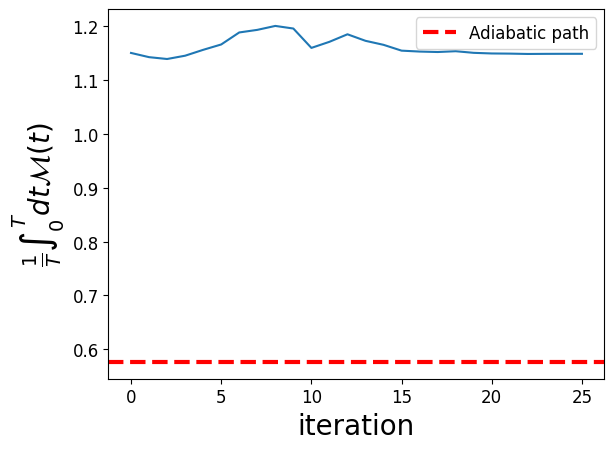

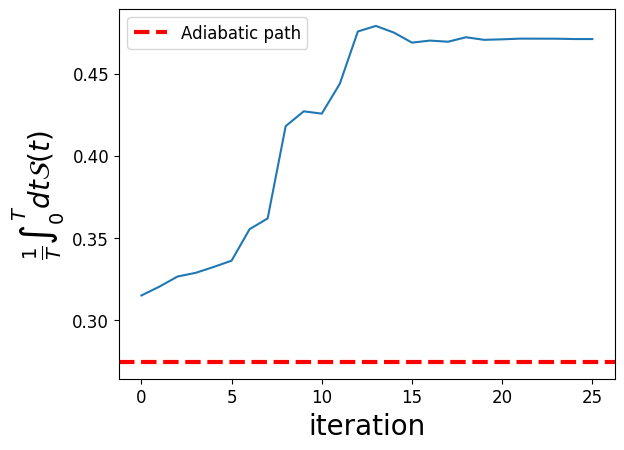

In [175]:
plt.plot(np.arange(len(total_magic)), total_magic / time[-1])
plt.axhline(
    np.average(magic_gs_level),
    color="red",
    linestyle="--",
    linewidth=3,
    label="Adiabatic path",
)
plt.xlabel("iteration", fontsize=20)
plt.ylabel(r"$\frac{1}{T}\int_0^T dt  \mathcal{M}(t) $", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()


plt.plot(np.arange(len(total_entanglement)), total_entanglement / time[-1])
plt.axhline(
    np.average(entanglement_entropy_gs_level_history),
    color="red",
    linestyle="--",
    linewidth=3,
    label="Adiabatic path",
)
plt.xlabel("iteration", fontsize=20)
plt.ylabel(r"$\frac{1}{T}\int_0^T dt  \mathcal{S}(t) $", fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()


np.savez(
    f"data/history_optimal_control_{tau:.2f}.npz",
    total_magic=np.asarray(total_magic),
    total_entanglement=np.asarray(total_entanglement),
    energy=np.asarray(model.history),
)

##### Probabilities

In [ ]:
from scipy.sparse.linalg import eigsh, expm_multiply

# ── initialization ────────────────────────────────────────────────────────────
energy_optimal_control = np.zeros(time_steps)
probabilities_optimal_control = np.zeros((time_steps, nlevels))

# ── time evolution ────────────────────────────────────────────────────────────
for i, t in enumerate(time):

    hamiltonian_t = (1 - t / tau) * driver_hamiltonian + (t / tau) * target_hamiltonian

    # ── diagonalize ───────────────────────────────────────────────────────
    eigenstates_raw = eigenstates_t[:, order].astype(complex)  # raw — for probabilities
    # overlap
    probabilities_optimal_control[i] = (
        np.einsum("i,ia->a", psi_history_optimalcontrol[i].conj(), eigenstates_raw)
        * np.einsum(
            "i,ia->a", psi_history_optimalcontrol[i].conj(), eigenstates_raw
        ).conj()
    )
    energy_optimal_control[i] = np.real(
        np.vdot(
            psi_history_optimalcontrol[i], hamiltonian_t @ psi_history_optimalcontrol[i]
        )
    )


print(probabilities_optimal_control[-1, 0])
print(spectrum.shape)
print(
    time[np.argmin(spectrum[:, 2] - spectrum[:, 0])],
    np.min(spectrum[:, 2] - spectrum[:, 0]),
)

min_time_gap = time[np.argmin(spectrum[:, 2] - spectrum[:, 0])]

/tmp/ipykernel_211739/98082351.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  probabilities_optimal_control[i] = (


0.9978652705637673
(3000, 10)
179.45981993998 1.1004542865493292


##### Plot probabilities

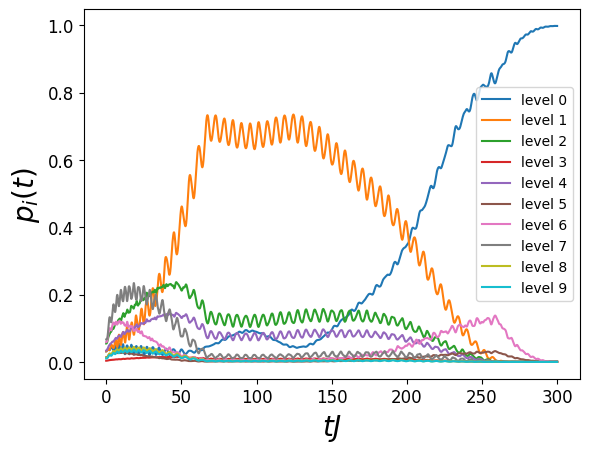

In [ ]:
for i in range(nlevels):
    plt.plot(time, probabilities_optimal_control[:, i], label=f"level {i}")
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$p_i(t)$", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

##### Energy spectrum

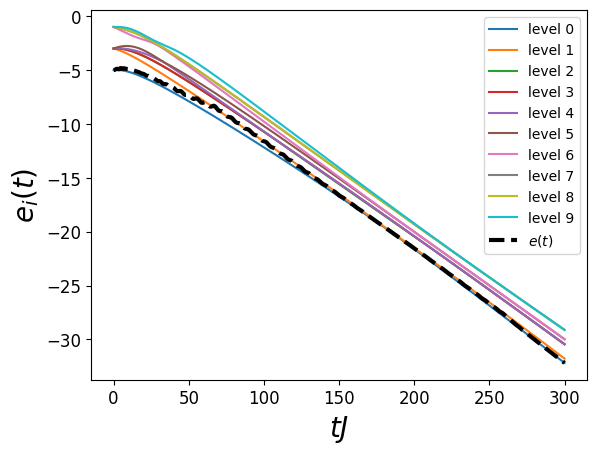

final energy: -32.17609466447175


In [ ]:
for i in range(spectrum.shape[1]):
    plt.plot(time, spectrum[:, i], label=f"level {i}")
plt.plot(
    time,
    energy_optimal_control,
    color="black",
    linestyle="--",
    linewidth=3,
    label=r"$e(t)$",
)
plt.xlabel(r"$t J$", fontsize=20)
plt.ylabel(r"$e_i(t)$", fontsize=20)
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend()
plt.show()

print("final energy:", energy_optimal_control[-1])

#### Notes / next steps

- If `tau` is too short for the linear ramp to show meaningful transfer (very likely, given the
  exponentially small gap at this AC), try a bisection search over `tau` as in Cote et al.
  Algorithm 2 / Werner et al. Sec. III — find the minimal `tau` for which optimal control reaches
  a target residual energy threshold, for a few different `N`.
- To push to larger `N` (Werner et al. go up to N=39,69 via the Nambu/free-fermion formalism),
  the sector projection here only gives a constant-factor (2x) reduction — genuinely larger `N`
  needs the free-fermion representation of the ring model (quadratic in Z, off-diagonal in X),
  which connects directly to the open question already in Magic4Annealing about the Nambu/BdG
  route to SRE for the 1D Ising chain.
- AGP/counterdiabatic driving and the quench-limit sections from `AvoidedCrossing.ipynb` were
  intentionally left out of this notebook (per scope discussion) since they're less central to
  the Cote/Werner frustrated-ring story specifically — happy to add them if useful.
